In [ ]:
!pip install -U langchain "langchain[openai]"


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import dotenv
dotenv.load_dotenv()

True

### Tool 기초

In [4]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

In [5]:
response = model.invoke("현재 한국 날씨 어때?")

In [7]:
response.content

'지금 당장 실시간 날씨를 바로 알려주는 기능은 없어요. 다만 도와드릴 수 있는 건 두 가지예요:\n\n- 특정 도시(예: 서울, 부산, 대전 등)의 계절별 일반적인 날씨 경향이나 특징을 알려드림\n- 현재/오늘/주간 예보를 확인하는 방법을 안내해 드림\n\n원하시면 어느 지역의 현재 날씨가 궁금한지(도시/지역 이름)와 시간대(현재/오늘/이번 주 중 궁금한 시간대)를 알려주세요. 제가 그 지역의 일반적인 계절 특징이나 예보를 설명해 드리겠습니다.\n\n실시간으로 확인하려면:\n- 스마트폰의 날씨 앱 열기\n- 인터넷에서 “도시 이름 현재 날씨” 검색(예: “서울 현재 날씨”)\n- 기상청(KMA) 홈페이지나 주요 포털 날씨 서비스 이용\n\n어떤 형식으로 도와드릴까요? 특정 도시를 말씀해 주면 도움이 될 만한 정보나 체크리스트를 바로 정리해 드릴게요.'

In [9]:
from langchain.tools import tool

@tool
def get_weather(location : str) -> str:
    """ 특정 지역의 날씨 정보를 제공하는 도구"""
    return f"{location}의 날씨는 맑고, 영하 2도입니다."

In [10]:
from langchain.agents import create_agent

agent = create_agent(
    model,
    tools=[get_weather]
    )

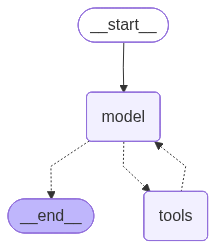

In [11]:
agent

In [13]:
# agent.invoke(
#     {"messages": [{"role": "user", "content": "서울 날씨 어때요?"}]},
# )

result = agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 어때요?"}]}
)

In [16]:
result["messages"][-1].content

'서울은 오늘 맑고 기온은 영하 2도예요. 외출 시 두꺼운 외투에 모자나 목도리로 체온을 잘 유지하시길 권합니다. 필요하면 시간대별 예보나 내일 날씨도 알려드릴게요. 다른 도시나 더 자세한 정보도 원하나요?'

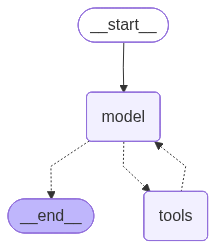

In [17]:
from IPython.display import Image, display

# 그래프 구조 확인
display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "전주 날씨 어때요?"}]},
)

In [ ]:
result

{'messages': [HumanMessage(content='전주 날씨 어때요?', additional_kwargs={}, response_metadata={}, id='887f8ac1-c0df-4d38-83a6-41effb781c2d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 216, 'prompt_tokens': 139, 'total_tokens': 355, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJX1MNortFuwR0SBXvWiLL73XAnrT', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cefab-bdd1-70c2-a0ac-156cce995df0-0', tool_calls=[{'name': 'get_weather', 'args': {'location': '전주'}, 'id': 'call_0B3BDI158v5DcqOhTuoguFU9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 139, 'output_tokens': 216, 'total_to

## Tool 응용 1

In [18]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """`a`와 `b` 덧셈.

    Args:
        a: First int
        b: Second int
    """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """`a`와 `b` 곱셈.

    Args:
        a: First int
        b: Second int
    """
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """`a`와 `b` 나눗셈.

    Args:
        a: First int
        b: Second int
    """
    return a / b

In [19]:
tools = [add, multiply, divide]

In [20]:
agent = create_agent(
    model=model,
    tools = tools
)

In [21]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "42 + 3 * 23은 뭔가요?"}]},
)

In [22]:
result

{'messages': [HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='bfd44fcb-de32-4802-89e2-9d15b6d186ba'),
  AIMessage(content='111입니다.\n\n설명: 표준 연산 규칙에서 곱셈이 먼저 수행되므로 3 × 23 = 69이고, 여기에 42를 더하면 42 + 69 = 111이 됩니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 315, 'prompt_tokens': 244, 'total_tokens': 559, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DSX0eUY4NegWX5RelYfmDW9nFamq9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d6f84-711a-7ad2-af70-d2651b653ba7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 244, 'output_tokens': 315, 'total_tokens': 559, 'input_token_

In [23]:
agent = create_agent(
    model,
    tools,
    system_prompt="당신은 유능한 수학 선생님입니다. 사칙 연산 요청 시 모든 단계에서 Tool을 이용하세요."
)

In [24]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "42 + 3 * 23은 뭔가요?"}]},
)

In [25]:
result

{'messages': [HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='162a7180-2387-471e-8cf4-33eef06132b9'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 410, 'prompt_tokens': 274, 'total_tokens': 684, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DSX2zDpsD97jmcXf7lXaQK6FymfTS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6f86-a764-72d3-b96b-67fd4eb7e3ac-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_u6IKbV4Zaxi0AZzFmFyqyEmB', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 274, 'output_tokens': 410, 'total

In [ ]:
{'messages': [
    HumanMessage(content='42 + 3 * 23은 뭔가요?', additional_kwargs={}, response_metadata={}, id='d668f973-433b-43a6-832c-12f69d7a1d47'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 666, 'prompt_tokens': 271, 'total_tokens': 937, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0BtgC1vSXVOqkym1wLgdCHV0mg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e3ff5826-b8ae-45ef-b321-845634280cac-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_6JIP9XWGEL4Y8gsDf7kLMCns', 'type': 'tool_call'}], usage_metadata={'input_tokens': 271, 'output_tokens': 666, 'total_tokens': 937, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 640}}),
    ToolMessage(content='69', name='multiply', id='ce3260fd-d978-4f22-9ac8-7ecba8497b5c', tool_call_id='call_6JIP9XWGEL4Y8gsDf7kLMCns'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 302, 'total_tokens': 322, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0IzrIXR33PjGJkChQkJNBWEPNp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--79f83b57-4a2b-4ceb-8dd1-79bb8ac2907c-0', tool_calls=[{'name': 'add', 'args': {'a': 42, 'b': 69}, 'id': 'call_dYzyonAijap4wIkosXukpffe', 'type': 'tool_call'}], usage_metadata={'input_tokens': 302, 'output_tokens': 20, 'total_tokens': 322, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
    ToolMessage(content='111', name='add', id='a30c98b9-41e5-4496-aed3-044c02028346', tool_call_id='call_dYzyonAijap4wIkosXukpffe'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 666, 'prompt_tokens': 333, 'total_tokens': 999, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0KeTPVjeebFxGf8IXHbmsLUKQ9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--3e09231b-dfd0-4190-9c22-024988cc4389-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_7i9W8KYCfoyL0V5YM3hA9CNM', 'type': 'tool_call'}], usage_metadata={'input_tokens': 333, 'output_tokens': 666, 'total_tokens': 999, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 640}}),
    ToolMessage(content='69', name='multiply', id='f041ffd3-626e-4541-9ea7-db7c200a49ef', tool_call_id='call_7i9W8KYCfoyL0V5YM3hA9CNM'),
    AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 922, 'prompt_tokens': 364, 'total_tokens': 1286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 896, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0QZAwvbco2nLwS2UlXoKoQJ2zB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--eb606c0c-8c16-4789-928d-2ed8e902074f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 23}, 'id': 'call_bUU09sNKZb2CMKxPwn3dc7pW', 'type': 'tool_call'}], usage_metadata={'input_tokens': 364, 'output_tokens': 922, 'total_tokens': 1286, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 896}}),
    ToolMessage(content='69', name='multiply', id='9ae49215-1418-4f1b-88e3-c32caa9dd511', tool_call_id='call_bUU09sNKZb2CMKxPwn3dc7pW'),
    AIMessage(content='정답은 111입니다.\n\n설명:\n- 먼저 곱셈의 순서를 따릅니다: 3 * 23 = 69\n- 그리고 남은 더하기를 수행합니다: 42 + 69 = 111\n\n추가로, 계산 과정을 한 번에 확인하는 방법도 보여드리면:\n- 42 + 3 * 23 = 42 + (3 * 23) = 42 + 69 = 111\n\n필요한 다른 연산이 있으면 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 395, 'total_tokens': 510, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CYN0Ywh5LSATE3IezdrYTcoik9Abu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--79aa9996-99f3-4463-9986-b33c4f53d706-0', usage_metadata={'input_tokens': 395, 'output_tokens': 115, 'total_tokens': 510, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
    ]
}

## Tool 응용 2 - 알라딘 API

In [ ]:
response = model.invoke("현재 알라딘에서 베스트셀러 Top10 뭐야?")

In [ ]:
print(result["messages"][-1].content)

In [1]:
from langchain.tools import tool
from typing import List, Dict, Any
import os

import requests

@tool
def fetch_aladin_bestseller_top10() -> List[Dict[str, Any]]:
    """
    알라딘 베스트셀러 목록을 조회하고 Top N개(기본 10)를 반환합니다.
    """
    url = "http://www.aladin.co.kr/ttb/api/ItemList.aspx"
    params = {
        "ttbkey": os.environ["ALADIN_API_KEY"],
        "QueryType": "Bestseller",
        "MaxResults": 10,
        "start": 1,
        "SearchTarget": "Book",
        "output": "js",
        "Version": "20131101"
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data = resp.json()
    items = data.get("item", [])
    top10 = items[:10]
    return top10

In [2]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-4o")

agent = create_agent(model, tools=[fetch_aladin_bestseller_top10])

In [3]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "현재 알라딘에서 베스트셀러 Top10 뭐야?"}]},
)

In [ ]:
print(response)

{'messages': [HumanMessage(content='현재 알라딘에서 베스트셀러 Top10 뭐야?', additional_kwargs={}, response_metadata={}, id='1d404176-8eeb-4cf2-a674-565b86868a29'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 76, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_02e9bb85b6', 'id': 'chatcmpl-DSXUhSgwiKcoZ5lffmzVjEILdLxmG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6fa0-dfed-7973-aee6-bd216d09dc0d-0', tool_calls=[{'name': 'fetch_aladin_bestseller_top10', 'args': {}, 'id': 'call_CqgTpkVC4RE0gLyXyrqo3Eav', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens':

In [6]:
print(response["messages"][-1].content)

현재 알라딘에서 베스트셀러 Top 10은 다음과 같습니다:

1. **프로젝트 헤일메리**  
   저자: 앤디 위어  
   [책 링크](https://www.aladin.co.kr/shop/wproduct.aspx?ItemId=270454373&amp;partner=openAPI&amp;start=api)  
   ![표지](https://image.aladin.co.kr/product/27045/43/coversum/k692135851_3.jpg)

2. **캐릭터 심리 사전**  
   저자: 린다 N. 에델스타인  
   [책 링크](https://www.aladin.co.kr/shop/wproduct.aspx?ItemId=388092141&amp;partner=openAPI&amp;start=api)  
   ![표지](https://image.aladin.co.kr/product/38809/21/coversum/k582137986_2.jpg)

3. **2026 제17회 젊은작가상 수상작품집**  
   저자: 김채원 외  
   [책 링크](https://www.aladin.co.kr/shop/wproduct.aspx?ItemId=389894398&amp;partner=openAPI&amp;start=api)  
   ![표지](https://image.aladin.co.kr/product/38989/43/coversum/k232137415_1.jpg)

4. **무례한 세상에서 나를 지키는 법**  
   저자: 발타사르 그라시안  
   [책 링크](https://www.aladin.co.kr/shop/wproduct.aspx?ItemId=388169547&amp;partner=openAPI&amp;start=api)  
   ![표지](https://image.aladin.co.kr/product/38816/95/coversum/k382137182_1.jpg)

5. **사랑이 있으니 살아집디다**  
   저자: 유시민, 김세라  
   

## Memory

In [1]:
tools=[]

In [2]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

model = init_chat_model(model="gpt-4o")

agent = create_agent(
    model,
    tools,
    checkpointer = InMemorySaver()
)

In [3]:
import dotenv
dotenv.load_dotenv()   

response = agent.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요, 저는 손수호입니다."}]},
    {"configurable": {"thread_id": "1"}}
)

In [4]:
print(response["messages"][-1].content)

안녕하세요, 손수호님! 만나서 반갑습니다. 어떻게 도와드릴까요?


In [7]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "제 이름이 뭐라고 했죠?"}]},
    {"configurable": {"thread_id": "1"}}

 )

In [8]:
print(response["messages"][-1].content)

이전 메시지에서 본인을 "손수호"라고 소개하셨기 때문에 그 이름을 사용했습니다. 이 이름이 맞는지 확인하기 어렵지만, 그렇게 말씀하셨기 때문에 그렇게 인식했습니다. 더 궁금한 사항이 있으면 말씀해 주세요!


In [9]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "제 이름이 뭐라고 했죠?"}]},
    {"configurable": {"thread_id": "2"}}
 )

In [10]:
print(response["messages"][-1].content)

죄송하지만, 제가 당신의 이름을 알고 있을 수는 없습니다. 개인정보는 저장하거나 접근할 수 없으니, 혹시 다른 질문이나 도움이 필요한 부분이 있다면 알려주세요!


In [11]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "지금까지 무슨 얘기 나눴죠?"}]},
    {"configurable": {"thread_id": "1"}},
)

In [12]:
for i, msg in enumerate(response["messages"]):
    print(f"--- Message {i+1} ---")
    print(msg.content)
    print()

--- Message 1 ---
안녕하세요, 저는 손수호입니다.

--- Message 2 ---
안녕하세요, 손수호님! 만나서 반갑습니다. 어떻게 도와드릴까요?

--- Message 3 ---
제 이름이 무엇인가요?

--- Message 4 ---
죄송하지만, 저는 해당 상호작용에서 제공되지 않은 정보를 통해 사용자의 이름이나 기타 개인 정보를 식별할 수 없습니다. "손수호"라는 이름을 예시로 말씀하셨기 때문에 그렇게 인식했습니다. 다른 질문이 있으면 언제든지 말씀해 주세요!

--- Message 5 ---
제 이름이 뭐라고 했죠?

--- Message 6 ---
이전 메시지에서 본인을 "손수호"라고 소개하셨기 때문에 그 이름을 사용했습니다. 이 이름이 맞는지 확인하기 어렵지만, 그렇게 말씀하셨기 때문에 그렇게 인식했습니다. 더 궁금한 사항이 있으면 말씀해 주세요!

--- Message 7 ---
지금까지 무슨 얘기 나눴죠?

--- Message 8 ---
당신은 처음에 자신을 "손수호"라고 소개했으며, 그 후에 제가 당신의 이름을 알 수 있는지를 물었습니다. 그에 대해 저는 제공된 정보에 기반하여 "손수호"라는 이름을 인식했다고 답변드렸습니다. 그리고 다시 한 번 이름 확인 요청을 하셔서 같은 답변을 드렸습니다. 추가로 궁금한 점이 있으시면 언제든지 말씀해 주세요!



In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "지금까지 무슨 얘기 나눴죠?"}]},
    {"configurable": {"thread_id": "2"}},
)

In [ ]:
for i, msg in enumerate(response["messages"]):
    print(f"--- Message {i+1} ---")
    print(msg.content)
    print()

## Middleware

### Built-in middleware

#### LLM tool emulator

In [13]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [15]:
from langchain.agents.middleware import LLMToolEmulator

agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano")
    ]

)

In [16]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "최근 온 메일 확인하고 알아서 답장해줘."}
        ]
    }
)

In [17]:
response

{'messages': [HumanMessage(content='최근 온 메일 확인하고 알아서 답장해줘.', additional_kwargs={}, response_metadata={}, id='6a948145-0743-49a5-b1a1-22480ac952ef'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 788, 'prompt_tokens': 189, 'total_tokens': 977, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 768, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DTOF1xPptoOYTCLC9hvz6NPrktCI2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7bb6-bf54-7590-b74e-7d76f09c09ff-0', tool_calls=[{'name': 'read_email_tool', 'args': {}, 'id': 'call_WtSmQn3hpOakviFMxeQYiqIQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 189, 'output_tokens': 788, 'total_to

In [ ]:
print(response["messages"][-1].content)

In [ ]:
print(response)

#### Todo list

In [ ]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [18]:
from langchain.agents.middleware import LLMToolEmulator, TodoListMiddleware


agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
        TodoListMiddleware(),
    ],
)

In [19]:
result = agent.invoke({
    "messages": [
            {"role": "user", "content": "온 메일 다 확인한 뒤 나한테 요약해 보고해. 그 다음 답장 작성해 회신 보내줘. 마지막으로 어떻게 보냈는지 보고하고."}
    ]
})

In [20]:
print(result["messages"][-1].content)

다 읽고 정리한 뒤 답장까지 보냈습니다. 아래에 요약과 발송 내역을 정리합니다.

1) 읽은 3통 이메일 요약
- EMAIL-202604110915
  - 보낸이: 김수민 <sumin.kim@example.com>
  - 제목: 프로젝트 업데이트 및 내일 회의
  - 날짜/상태: 2026-04-11 09:15, 읽지 않음
  - 핵심 내용: 이번 주에 API 연동 및 프런트 엔드 마감까지 완료. 내일(오전 10시) 스탠드업 회의에서 전체 진행 상황 공유 예정.
- EMAIL-EMAIL-202604110802
  - 보낸이: 네이버 클라우드 <no-reply@navercloud.com>
  - 제목: 결제 내역 확인 및 영수증
  - 날짜/상태: 2026-04-11 08:02, 읽지 않음 여부 네이버 클라우드 이메일은 이미 읽었는지 여부 확인 필요
  - 핵심 내용: 고객의 최근 결제 내역과 영수증 첨부. 다운로드 안내.
- EMAIL-202604102245
  - 보낸이: 서비스 운영팀 <ops@example.com>
  - 제목: 서버 점검 안내
  - 날짜/상태: 2026-04-10 22:45, 읽음 여부: 읽지 않음
  - 핵심 내용: 다음 주 월요일 02:00–04:00에 보안 패치 적용으로 서비스 일시 중지 예정. 불편 최소화를 위한 협조 요청.

2) 각 이메일에 대한 답장 초안 (발신 대상 및 주요 포인트)
- 수민님께 Re: 프로젝트 업데이트 및 내일 회의
  - 초안 내용 (전송 버전): 
    안녕하세요 수민님,
    
    프로젝트 업데이트 공유 감사합니다. 이번 주 API 연동 및 프런트 엔드 마감까지 완료되었다는 점 잘 확인했습니다. 내일 오전 10시 스탠드업 회의에서 전체 진행 상황을 공유하겠습니다. 회의 전까지 공유해 주실 자료나 의제(예: 남은 이슈 목록, 우선순위)를 알려주시면 회의에 반영하겠습니다.
    
    감사합니다,
    담당자 드림
- 네이버 클라우드 문의에 대한 답장
  - 초안 내용:
    안녕하세요,


In [ ]:
print(result)

#### Human-in-the-loop

In [ ]:
from langchain.tools import tool

@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    최근 받은 이메일 3개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."


@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """이메일을 발송하는 도구"""
    return f"{to}에게 메일을 보냈습니다.\n제목: {subject}\n내용: {body[:40]}..."

In [21]:
from langchain.agents.middleware import LLMToolEmulator, HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver



agent = create_agent(
    model,
    tools=[send_email_tool, read_email_tool],
    # 체크포인터 연결
    checkpointer=InMemorySaver(),

    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False
                
            }
        )   
    ],
)

In [22]:
prompt = "무슨 메일 왔는지 확인해줘"

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
    {"configurable": {"thread_id": "HIL-a"}}
)

In [23]:
print(response["messages"][-1])

content='다음은 최근에 받은 메일 3개입니다:\n\n1. **보낸 사람:** Sophia Müller <sophia.mueller@example.de>  \n   **날짜:** 2026-04-11 09:32  \n   **제목:** Re: Quarterly report draft – feedback needed  \n   **내용:**  \n   안녕하세요,  \n   첨부된 최신 분기 보고서 초안을 검토해 주십시오(Q1). 주요 내용은 6% 증가한 수익, 향상된 운영 현금 흐름, 및 업데이트된 예측입니다. KPIs를 검토하시고 수요일 종일까지 피드백을 주시면 감사하겠습니다. 차트에 대한 수정이 필요하시면 회신해 주세요.  \n   **첨부 파일:** quarterly_q1_draft.pdf\n\n2. **보낸 사람:** Tech Support <support@acmecorp.com>  \n   **날짜:** 2026-04-11 09:15  \n   **제목:** Ticket #23841: password reset failure – update  \n   **내용:**  \n   안녕하세요,  \n   비밀번호 재설정 오류의 원인을 파악했고 수정 작업을 완료했습니다. 계정에서 재설정을 시도해 보십시오. 여전히 실패할 경우, 정확한 오류 메시지를 회신해 주세요.  \n   **티켓 번호:** #23841  \n   **첨부 파일 없음**\n\n3. **보낸 사람:** Dana Lee <dana.lee@example.com>  \n   **날짜:** 2026-04-11 08:48  \n   **제목:** Weekend camping trip planning  \n   **내용:**  \n   안녕하세요,  \n   이번 주말 캠핑 여행 계획 아직 유효한가요? 제가 텐트, 스토브, 스낵 몇 가지를 준비할 수 있습니다. 계획과 식단 제한이 있는지 알려 주세요.  \n   **Best,**  \n   Dana  \n\n추가 문의 사항이 있으면 언제든지 알려주세

In [24]:
prompt = "교수님한테 내일 찾아뵙겠다는 메일 작성해서 보내줘."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
    {"configurable": {"thread_id": "HIL-b"}}
)

In [25]:
response["messages"][-1].content

'교수님께 보낼 이메일 주소를 알려주시면 메일을 작성해 드리겠습니다.'

In [27]:
prompt = "shd437s@naver.com"

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
    {"configurable": {"thread_id": "HIL-b"}}
)

In [28]:
response

{'messages': [HumanMessage(content='교수님한테 내일 찾아뵙겠다는 메일 작성해서 보내줘.', additional_kwargs={}, response_metadata={}, id='fb98f576-e665-4c43-b2f9-4b4763991b42'),
  AIMessage(content='교수님께 보낼 이메일 주소를 알려주시면 메일을 작성해 드리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 115, 'total_tokens': 137, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8cb92c267', 'id': 'chatcmpl-DTOloEG7XDULI10bRA5FjWkAkooxG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7bd5-c590-7d53-a2e9-f8084fb012d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 115, 'output_tokens': 22, 'total_tokens': 137, 'input_token_details': {'audio': 0, 'cache_read

In [29]:
response["messages"][-1].content

''

#### PII Detection

In [30]:
@tool
def save_customer_feedback(feedback: str) -> str:
    """고객 피드백을 저장하는 도구"""
    return f"📥 고객 피드백 저장 완료: {feedback}"

In [40]:
from langchain.agents.middleware import LLMToolEmulator, PIIMiddleware


agent = create_agent(
    model,
    tools=[save_customer_feedback],
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
        # 이메일 주소는 전부 마스킹 처리
        PIIMiddleware(
            "email", strategy="redact", apply_to_input=True)
        ,
        # 카드번호는 마지막 4자리만 남기고 나머지 마스킹 처리
        PIIMiddleware(
            "credit_card", strategy="mask", apply_to_input=True,
        ),

        # API Key 형태(sk-로 시작하는 32자리)는 감지되면 실행 중단
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-X0-9]{32}",
            strategy="block",
            apply_to_input=True
        )

    ],
)

In [32]:
prompt = "안녕하세요. 저는 수호(이메일 : shd437s@example.com)입니다. 어제 아이폰 구매했는데 결제가 잘 됐는지 확인 부탁합니다."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [33]:
print(response)

{'messages': [HumanMessage(content='안녕하세요. 저는 수호(이메일 : [REDACTED_EMAIL])입니다. 어제 아이폰 구매했는데 결제가 잘 됐는지 확인 부탁합니다.', additional_kwargs={}, response_metadata={}, id='58a4d097-dc3c-4be5-8358-c819bd1f3a85'), AIMessage(content='안녕하세요, 수호님. 결제 확인을 위해서는 고객 지원팀에 직접 문의하시거나 해당 구매처의 웹사이트나 앱을 통해 구매 내역을 확인하시는 것이 좋습니다. 온라인으로 결제를 진행하셨다면, 이메일로 전송된 구매 확인 메일을 확인해보시고, 문제가 있으시다면 결제하신 카드사에 문의해보시는 것도 도움이 될 수 있습니다.\n\n추가적으로 다른 도움이 필요하신지요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 85, 'total_tokens': 185, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e2564de534', 'id': 'chatcmpl-DTOvAREW7iqzxdt98bBCTsuDLMZRF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019

In [34]:
prompt = "안녕하세요. 저는 수호(이메일 : shd437s@example.com)입니다. 제 카드번호는 1234123443214321 입니다. 결제 문제를 해결해주세요."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [35]:
print(response)

{'messages': [HumanMessage(content='안녕하세요. 저는 수호(이메일 : [REDACTED_EMAIL])입니다. 제 카드번호는 ************4321 입니다. 결제 문제를 해결해주세요.', additional_kwargs={}, response_metadata={}, id='84a2a802-246c-4b68-9ed3-b007172b1a28'), AIMessage(content='안녕하세요, 수호님. 결제 문제로 불편을 드려 죄송합니다. 하지만 결제 문제는 개인 정보와 관련이 있어 여기서 직접 해결할 수는 없습니다. 온라인 뱅킹이나 카드 서비스 센터에 직접 문의하시기 바랍니다. 추가적인 도움이 필요하시면 언제든지 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 84, 'total_tokens': 156, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e2564de534', 'id': 'chatcmpl-DTOx8j3UzFPxOjWIhbMmjglUZKb1R', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7be0-76bd-7073-a611-53ba73af4c2a-0', tool_c

In [41]:
prompt = "제 open-ai API 키는 sk-1234567890abcdef1234567890abcdef입니다."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

PIIDetectionError: Detected 1 instance(s) of api_key in text content

#### Custom PII Detector

In [36]:
phone_number_detector_regex = r"\b(010)[-\s]?(\d{3,4})[-\s]?(\d{4})\b"

# 커스텀 PII 미들웨어 생성
phone_masking_middleware = PIIMiddleware(
    # pii_type: "phone_number" 라는 커스텀 이름 지정
    pii_type="phone_number",

    # detector: 위에서 만든 정규식 전달
    detector=phone_number_detector_regex,
    # strategy: "mask" (마스킹)
    # 마스킹은 기본적으로 마지막 4자리를 제외하고 마스킹
    strategy="mask",
    # apply_to_input: 사용자 입력에 적용
    apply_to_input=True
)

In [37]:
agent = create_agent(
    model=model,
    tools=[save_customer_feedback],
    middleware=[phone_masking_middleware]
)

In [38]:
prompt = "안녕하세요, 제 핸드폰 번호는 010-1234-5678 입니다. 등록해주세요."

response = agent.invoke(
    {"messages": [{"role": "user", "content": prompt}]},
)

In [39]:
print(response)

{'messages': [HumanMessage(content='안녕하세요, 제 핸드폰 번호는 ****5678 입니다. 등록해주세요.', additional_kwargs={}, response_metadata={}, id='c848a5f8-f535-4f95-b1f3-adacc32f616a'), AIMessage(content='안녕하세요! 하지만 보안을 위해 개인 정보, 특히 전화번호와 같은 민감한 정보를 처리하거나 저장할 수 없습니다. 다른 궁금한 점이나 도움이 필요하신 부분이 있다면 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 66, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_10ed490cb0', 'id': 'chatcmpl-DTOzUlvc2s0LAuCojXPzb1xa540uZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7be2-b496-79f3-9a9e-05274fbe3c97-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 66, 'output_tokens': 45, 

#### Summarize Memory

In [ ]:
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model,
    tools,
    middleware=[
        SummarizationMiddleware(
            model="gpt-5-nano",
            trigger={"message": 5},
            keep={"messages": 10},
            trim_tokens_to_summarize=4000

        )
    ],
    checkpointer=InMemorySaver(),
)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요! 저는 Jay입니다."}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "저는 AI 강사입니다."}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "저는 서울에 살고 있어요"}]},
    {"configurable": {"thread_id": "4"}}
)

In [ ]:
print(result["messages"][-1].content)

## Structured output

In [42]:
from langchain.tools import tool
from typing import List, Dict


# 이메일 전송 도구
@tool
def send_email_tool(to: str, subject: str, body: str) -> str:
    """
    지정한 이메일 주소로 메일을 보내는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 전송되었습니다.\n수신자: {to}\n제목: {subject}\n내용: {body[:50]}..."


# 이메일 읽기 도구
@tool
def read_email_tool(limit: int = 3) -> List[Dict[str, str]]:
    """
    고객이 온라인 쇼핑몰에 보낸 컴플레인, 문의, 혹은 확인 관련 이메일 1개를 읽는 도구입니다.
    """
    return f"✅ 이메일이 성공적으로 조회되었습니다."

In [43]:
from pydantic import BaseModel, Field
from typing import Literal

# Structured Output 정의
class EmailAnalysis(BaseModel):
    """이메일 내용을 분석한 결과 구조."""
    intent: Literal["complaint", "inquiry", "confirmation", "other"] = Field(
        description="이메일의 주요 의도 (예: complaint=불만, inquiry=문의, confirmation=확인, other=기타)"
    )
    sentiment: Literal["positive", "negative", "neutral"] = Field(description="이메일의 감정 상태")
    summary: str = Field(description="이메일 내용 요약")
    next_action: str = Field(description="에이전트가 수행해야 할 다음 단계 (예: 회신, 확인, 무시 등)")

In [44]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.agents.middleware import LLMToolEmulator

agent = create_agent(
    model="gpt-5-nano",
    tools=[send_email_tool, read_email_tool],
    response_format=ToolStrategy(EmailAnalysis),
    middleware=[
        LLMToolEmulator(model="gpt-5-nano"),
    ],
)

In [45]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "최근 온 메일 확인하고 고객의 의도와 감정, 요약, 그리고 어떤 행동이 필요한지 분석하세요."}
        ]
    }
)

In [46]:
response

{'messages': [HumanMessage(content='최근 온 메일 확인하고 고객의 의도와 감정, 요약, 그리고 어떤 행동이 필요한지 분석하세요.', additional_kwargs={}, response_metadata={}, id='a6e6f858-4711-4c9b-b991-af8c81a32118'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 985, 'prompt_tokens': 340, 'total_tokens': 1325, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 960, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DTPCTOrI5vV66DktNuwgFXfm0Hw4p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7bee-f73d-7240-9f72-1f4651db5b6b-0', tool_calls=[{'name': 'read_email_tool', 'args': {'limit': 1}, 'id': 'call_PYtLenqLeLoJrUMiJ2sn5aml', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

In [47]:
import re

text = str(response["messages"])

tool_messages = re.findall(r"ToolMessage\(content='(.*?)'", text, re.DOTALL)

for msg in tool_messages:
    print(msg.replace("\n", " "))

From: 이수민 <sumin@example.com>\nTo: support@onlinemall.co\nDate: 2026-04-11 10:42\nSubject: 주문번호 20260411001 배송 지연 관련 문의드립니다\n\nBody:\n\n안녕하세요. 며칠 전 주문한 상품의 배송이 아직 도착하지 않아 문의드립니다.\n\n- 주문번호: 20260411001\n- 주문일: 2026-04-04\n- 품목: 남성 봄 자켓 (사이즈 L)\n- 배송지: 서울시 마포구 상수동 77-4\n- 현재 상태: 배송예정일이 반복해서 변경되어 불안합니다.\n- 최근 트래킹: 1234567890\n\n요청 사항\n1) 현재 위치와 남은 배송 예상일을 자세히 알려 주세요.\n2) 배송 지연의 원인과 해결 기한을 구체적으로 안내해 주세요.\n3) 가능하다면 빠른 대체 배송 또는 부분 환불 여부를 안내해 주세요.\n\n연락가능 번호: 010-5555-1234\n감사합니다.\n- 수민 올림


In [48]:
response["structured_response"]

EmailAnalysis(intent='inquiry', sentiment='negative', summary='주문번호 20260411001의 배송 지연으로 도착 여부와 남은 배송 예상일, 원인과 해결 기한, 대체 배송 또는 부분 환불 가능 여부를 구체적으로 안내해 달라는 요청.', next_action='현재 배송 위치와 남은 배송 예상일, 지연 원인 및 해결 기한을 구체적으로 확인해 고객에게 회신하고, 대체 배송/부분 환불 가능 여부를 안내한다.')

In [ ]:
print(response["messages"])